### Загрузка и обработка данных

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import arch.unitroot as au
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os
import pickle
from statsmodels.tsa.x13 import x13_arima_analysis
import tempfile
import uuid
from typing import Dict, List, Tuple
import re
from pathlib import Path

import panel_utils
from panel_utils import (
    detect_outlier_regions_iqr,
    friedman_seasonality_test,
    run_panel_unit_root_tests,
    seasonal_adjust_panel_series,
    run_friedman_seasonality_tests,
)


In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')

old_clustering = 'region_cluster_dataset.pkl'
new_clustering = 'region_cluster_hank_dataset.pkl'
with open(old_clustering, 'rb') as f:
    df_region_cluster_old = pickle.load(f)
with open(new_clustering, 'rb') as f:
    df_region_cluster_new = pickle.load(f)
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [3]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg['Date'] = pd.to_datetime(df_reg['Date'])

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster_old, on='Region', how='left')
df_reg = df_reg.merge(df_region_cluster_new, on='Region', how='left')
# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_RF.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)
df_RF.rename(columns={'exc_rate_diff': 'd_Ex_Rate'}, inplace=True)

df_rf_extra = df_RF[['Date', 'ROISFIX', 'MIACR', 'Covid_dum', 'Sank_dum',
                'Exc_rate', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations',
                'MaP_Announcement', 'MaP_Tight_Announcement', 'MaP_Ease_Announcement',
                'MaP_Fact','MaP_Tight_Fact', 'MaP_Ease_Fact','REER', 'Oil_p', 'MaP_Announcement', 'MaP_Fact']].copy()

                     
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'CPI': 'CPI_reg'}, inplace=True)

#Расчетные показатели
df_reg['Oil_p_share_mining'] = df_reg['Oil_p'] * df_reg['Share_mining']

# Создаем лаги
df_reg['D_top5_rozn_lag1'] = df_reg.groupby('Region')['D_top5_rozn'].shift(1)
df_reg['CPI_reg_lag1'] = df_reg.groupby('Region')['CPI_reg'].shift(1)
df_reg['Def_Zadolg_Fl_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Fl'].shift(1)
df_reg['Def_Zadolg_Mort_lag1'] = df_reg.groupby('Region')['Def_Zadolg_Mort'].shift(1)
df_reg['Def_Zadolg_ConsCred_lag1'] = df_reg.groupby('Region')['Def_Zadolg_ConsCred'].shift(1)
df_reg['Cap_to_assets_lag1'] = df_reg.groupby('Region')['Cap_to_assets'].shift(1)

### Преобразование данных

In [4]:
# Сортировка
df_reg = df_reg.sort_values(['Region', 'Date']).copy()
df_RF = df_RF.sort_values(['Date']).copy()

# ============ ЛОГАРИФМИРОВАНИЕ ============ #

loan_vars = ['New_Loans_Fl', 'New_Loans_Mort', 'New_Loans_ConsCred', 'Fin_Dostup']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])
        
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]


# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ  ============ #

# Разности для логарифмов 
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

################################
# Разности переменных регионов #
################################

diff_vars_reg = ['Int_Rate_FL', 'Int_Rate_Mort', 'Int_Rate_ConsCred', \
            'Mon_Shock', 'ROISFIX', 'MIACR','CPI_reg', \
            'ln_New_Loans_Fl', 'ln_New_Loans_Mort', 'ln_New_Loans_ConsCred']

for var in diff_vars_reg:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

#################################
# Разности федеральных переменных
#################################

df_RF = df_RF.sort_values(['Date'])

diff_vars_fed = ['Key_Rate', 'ROISFIX', 'MIACR', 
                'IBC_constr_fed', 'IBC_torg_fed', 'IBC_auto_fed',]

for var in diff_vars_fed:
    d_var = f'd_{var}'
    df_RF[d_var] = df_RF[var].diff()


# Разделим шоки на позитивные и негативные
# Mon_Shock
df_reg['d_Mon_Shock_neg'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] < 0, 0)
df_reg['d_Mon_Shock_pos'] = df_reg['d_Mon_Shock'].where(df_reg['d_Mon_Shock'] > 0, 0)
# Разность ROISFIX 
df_reg['d_ROISFIX_neg'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] < 0, 0)
df_reg['d_ROISFIX_pos'] = df_reg['d_ROISFIX'].where(df_reg['d_ROISFIX'] > 0, 0)
# Разность MIACR 
df_reg['d_MIACR_neg'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] < 0, 0)
df_reg['d_MIACR_pos'] = df_reg['d_MIACR'].where(df_reg['d_MIACR'] > 0, 0)


#  Создаем взаимодействия для переменных процентных ставок
map_vars_int = ['d_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR',
    'd_MIACR_neg',
    'd_MIACR_pos',
]

z_vars_int = [
    'Covid_dum',
    'Sank_dum',
    'Cluster_1',
    'Cluster_2'
]
for m in map_vars_int:
    for z in z_vars_int:
        col_name = f"{m}_{z}"
        df_reg[col_name] = df_reg[m] * df_reg[z]


#  Создаем взаимодействия для переменных макропру
map_var_makro = [
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
]

z_vars_makro = [
    'D_top5_rozn_lag1',
    'Cap_to_assets_lag1',
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3'
]
for m in map_var_makro:
    for z in z_vars_makro:
        col_name = f"{m}_{z}"
        df_reg[col_name] = df_reg[m] * df_reg[z]


In [5]:
# СПИСОК ПЕРЕМЕННЫХ
conscred_vars = [
    'd_Int_Rate_ConsCred',          # Зависимая переменная
    'Int_Rate_ConsCred',
    'New_Loans_ConsCred',           # Выдача
    'New_Loans_ConsCred_mom',
    'New_Loans_Fl',
    'New_Loans_Fl_mom',
    'Zadolg_ConsCred',              # Задолженность
    'Zadolg_ConsCred_mom', 
    'Zadolg_Fl',
    'Zadolg_Fl_mom',
    'Def_Zadolg_ConsCred',          # Дефицит задолж
    'Def_Zadolg_Fl',
    'Cred_nagr',                    # Переменные состояния финансового рынка
    'Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Exc_rate',                     # Переменные ожиданий
    'Bonds_Rate_Correct_5Y',
    'Inflation_Expectations',
    #
    'Mon_Shock',                    # Шоки
    'd_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'ROISFIX',
    'MIACR',
    'Covid_dum',                    # Дамми
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]

exog_vars = [
    #Блок 1 - Зависимые переменные 
    'd_ln_New_Loans_Fl',
    'd_ln_New_Loans_Mort',
    'd_ln_New_Loans_ConsCred',
    #Блок 2 - Переменные интереса 
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Блок 3 - характеристики фин системы
    'D_top5_rozn_lag1',
    'ln_Fin_Dostup',
    'Def_Zadolg_Fl_lag1',
    'Def_Zadolg_Mort_lag1',
    'Def_Zadolg_ConsCred_lag1',
    'Cap_to_assets_lag1',
    #Блок 4 - макроэкономический
    'CPI_reg_lag1',
    'Oil_p_share_mining',
    'REER',
    #Блок 5 - монетарный 
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Блок 6 - кластеры
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3',
    #Блок 7 - шоки
    'Covid_dum',
    'Sank_dum'
]
other_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'ROISFIX'
]

choosed_vars = exog_vars
df_reg_analys = df_reg[['Region', 'Date'] + choosed_vars].copy()
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

### IQR чистка

In [8]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [x for x in choosed_vars if x not in [
    #Монетарные шоки
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_ROISFIX_neg',
    'd_ROISFIX_pos',
    'd_MIACR_neg',
    'd_MIACR_pos',
    #Макропру шоки
    'MaP_Tight_Announcement',
    'MaP_Ease_Announcement',
    'MaP_Tight_Fact',
    'MaP_Ease_Fact',
    #Кластеры
    'Cluster_HANK_1',
    'Cluster_HANK_2',
    'Cluster_HANK_3',
    'Cluster_1',
    'Cluster_2',
    #Санкции + ковид
    'Covid_dum',
    'Sank_dum',
    
    'd_IBC_constr',
    'd_IBC_torg',
    'd_IBC_auto',
    
    ]
]


# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# СОХРАНЕНИЕ СПИСКА РЕГИОНОВ
with Path('filter_for_cluster.pkl').open("wb") as saved:
    pickle.dump(good_regions_iqr, saved)

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 71 РЕГИОНОВ (IQR)
                      Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
              Алтайский край     80   0.0%            12   15.0%                                  KEEP
            Амурская область     80   0.0%            10   12.5%                                  KEEP
       Архангельская область     80   0.0%            12   15.0%                                  KEEP
        Астраханская область     80   0.0%             8   10.0%                                  KEEP
        Белгородская область     80   0.0%            11   13.8%                                  KEEP
            Брянская область     80   0.0%             8   10.0%                                  KEEP
        Владимирская область     80   0.0%             8   10.0%                                  KEEP
       Волгоградская область     80   0.0%             8   10.0%                                  KEEP
         Волог

### ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ

In [9]:
descriptive_df = df_reg_analys.drop(columns=['Date', 'Region', #'Int_Rate_ConsCred_lag1'
                                            ], axis = 1, inplace=False)


desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                          Среднее  Медиана  ст. откл.    Мин.     Макс.
d_ln_New_Loans_Fl           0.011    0.040      0.172  -0.936     0.738
d_ln_New_Loans_Mort         0.012    0.075      0.363  -1.826     1.162
d_ln_New_Loans_ConsCred     0.011    0.026      0.151  -0.973     0.814
MaP_Tight_Announcement      0.212    0.000      0.409   0.000     1.000
MaP_Ease_Announcement       0.138    0.000      0.344   0.000     1.000
MaP_Tight_Fact              0.212    0.000      0.409   0.000     1.000
MaP_Ease_Fact               0.138    0.000      0.344   0.000     1.000
D_top5_rozn_lag1            0.776    0.773      0.062   0.614     0.939
ln_Fin_Dostup               2.935    2.921      0.247   2.225     3.869
Def_Zadolg_Fl_lag1          4.177    4.169      0.891   1.407     8.234
Def_Zadolg_Mort_lag1        0.570    0.474      0.381   0.043     3.837
Def_Zadolg_ConsCred_lag1    7.412    7.431      1.299   2.154    12.338
Cap_to_asse

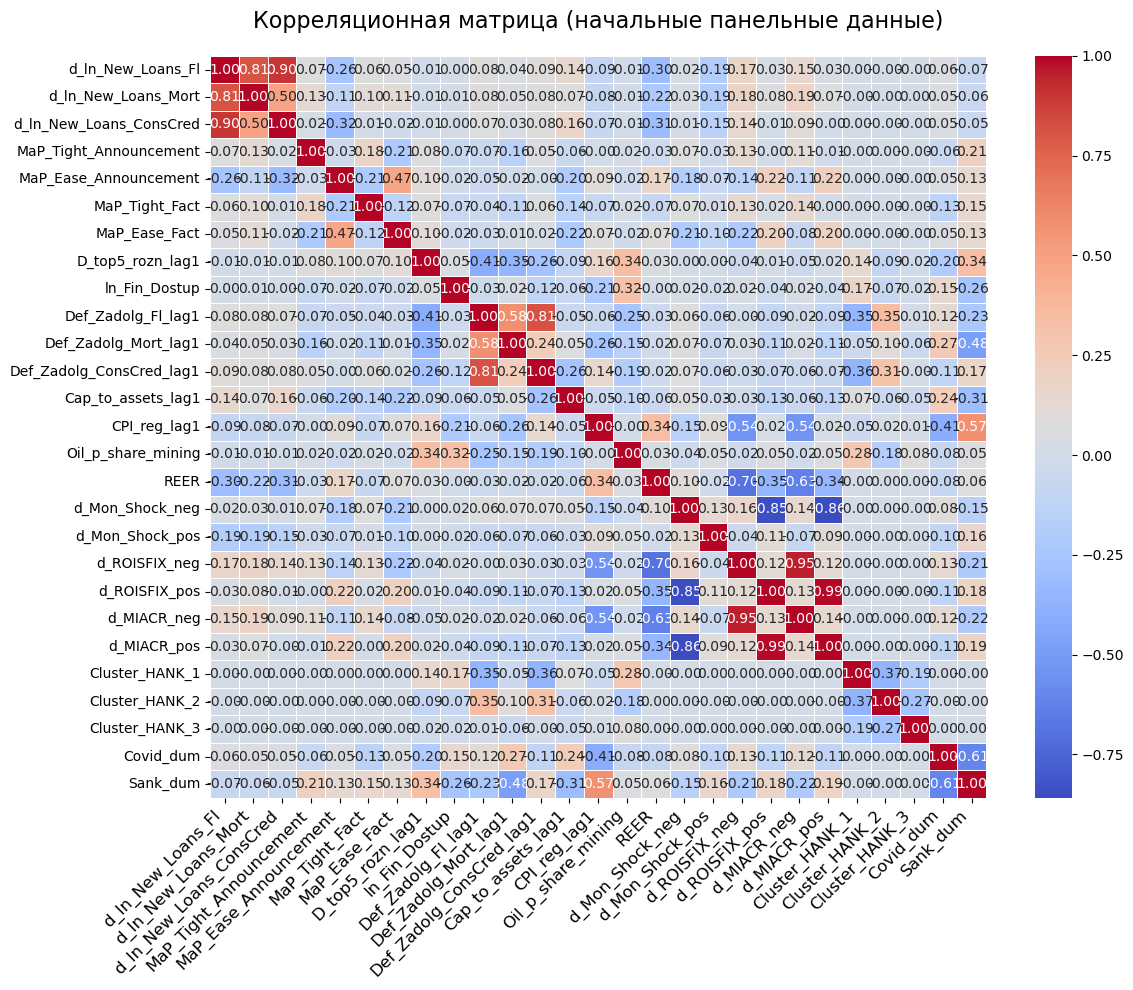

In [10]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

### Тест Фридмана на сезонность

In [11]:
friedman_df = df_RF.drop(columns=['Num_reg'], axis = 1, inplace=False)
friedman_summary = panel_utils.run_friedman_seasonality_tests(friedman_df, date_col='Date')


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                  Variable  Chi_Squared      P_Value  Has_Seasonality  N_Years  N_Months
             CAR_Indicator    12.107692 3.556030e-01            False        5        12
              D_Progr_mort    11.707692 3.860113e-01            False        5        12
                   ROISFIX     4.456963 9.545978e-01            False        5        12
                  Exc_rate    15.276923 1.701670e-01            False        5        12
                 d_Ex_Rate    17.892308 8.411333e-02            False        5        12
     Bonds_Rate_Correct_5Y     3.800000 9.754064e-01            False        5        12
    Inflation_Expectations    21.442254 2.906820e-02             True        5        12
      Nominal_Percent_Rate    11.863422 3.739965e-01            False        5        12
       Ent_conf_ind_mining    21.098503 3.236478e-02             True        5        12
Ent_conf_ind_manufactoring    27.583969 3.747413e-03             True        5    

In [ ]:
# # Extra diagnostics after Friedman test
# from panel_utils import run_seasonal_diagnostics

# series_list = [
#     'Inflation_Expectations',
#     'Ent_conf_ind_mining',
#     'Ent_conf_ind_manufactoring'
# ]

# for col in series_list:
#     if col in df_RF.columns:
#         run_seasonal_diagnostics(df_RF, 'Date', col, shock_year="2022")
#     else:
#         print(f'Missing column: {col}')


# # ####################################
# # # Сезонность есть даже с учётом шока в: Inflation_Expectations, Ent_conf_ind_manufactoring

### ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====

In [ ]:
df_reg_analys.columns

In [ ]:
# Сезонная корректировка 
# ! Для корректировки НЕОБХОДИМО добавить новые переменные в список функции seasonal_adjust_panel_wrapper в seasonal_adjustment.py
# 'Inflation_Expectations', 'Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining' потенциальные переменные
# Output_Index, IBC_constr, IBC_torg, IBC_auto, IBC_constr_fed, IBC_torg_fed, IBC_auto_fed

from seasonal_adjustment import seasonal_adjust_panel_wrapper

col_name_reg = ['Inflation_Expectations']  
df_reg_analys = seasonal_adjust_panel_wrapper(df_reg_analys, col_name_reg)

col_name_fed = ['Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining', 'd_IBC_constr_fed', 'd_IBC_torg_fed', 'd_IBC_auto_fed'] 
df_RF = seasonal_adjust_panel_wrapper(df_RF, col_name_fed)


In [ ]:
# Чистка датафрейма
to_delete_columns_reg = [col for col in df_reg_analys.columns if col.endswith('_seasonal') or col.endswith('_trend')]
to_delete_columns_RF = [col for col in df_RF.columns if col.endswith('_seasonal') or col.endswith('_trend')]

df_reg_analys.drop(columns=to_delete_columns_reg, inplace=True)
df_RF.drop(columns=to_delete_columns_RF, inplace=True)

# Разность инфляционных ожиданий
df_reg_analys['d_Inflation_Expectations'] = df_reg_analys['Inflation_Expectations_adj'].diff()

### Tестирование единичных корней

In [ ]:
# # ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
# print("="*70)

# # === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
# custom_vars = [x for x in choosed_vars if x not in [
#     'Cluster_1',
#     'Cluster_2',
#     'Covid_dum',
#     'Sank_dum']
# ]

# df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
# print("="*70)


# df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
# print("="*70)

# df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)

In [ ]:
# print("\n" + "="*70)
# print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
# print("="*70)
# # Запуск функции с пользовательским списком переменных
# results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)

### Добавление недостающих переменных

In [13]:
# Создаем нужные лаги
lag_vars = ['d_ln_New_Loans_Fl', 
            'd_ln_New_Loans_Mort',
            'd_ln_New_Loans_ConsCred',
            'MaP_Tight_Announcement',
            'MaP_Ease_Announcement',
            'MaP_Tight_Fact',
            'MaP_Ease_Fact'
           ]
for var in lag_vars:
    lag_var = f'{var}_lag1'
    df_reg[lag_var] = df_reg[var].shift(1)
#добавляем переменные
missing_vars = [
            'd_ln_New_Loans_Fl_lag1',
            'd_ln_New_Loans_Mort_lag1',
            'd_ln_New_Loans_ConsCred_lag1',
            'MaP_Tight_Announcement_lag1',
            'MaP_Ease_Announcement_lag1',
            'MaP_Tight_Fact_lag1',
            'MaP_Ease_Fact_lag1',
            'MaP_Tight_Announcement_D_top5_rozn_lag1',
            'MaP_Tight_Fact_D_top5_rozn_lag1',
            'MaP_Ease_Announcement_D_top5_rozn_lag1',
            'MaP_Ease_Fact_D_top5_rozn_lag1',
            'MaP_Tight_Announcement_Cap_to_assets_lag1',
            'MaP_Tight_Fact_Cap_to_assets_lag1',
            'MaP_Ease_Announcement_Cap_to_assets_lag1',
            'MaP_Ease_Fact_Cap_to_assets_lag1',
            'MaP_Tight_Announcement_Cluster_HANK_1',
            'MaP_Tight_Fact_Cluster_HANK_1',
            'MaP_Ease_Announcement_Cluster_HANK_1',
            'MaP_Ease_Fact_Cluster_HANK_1',
            'MaP_Tight_Announcement_Cluster_HANK_2',
            'MaP_Tight_Fact_Cluster_HANK_2',
            'MaP_Ease_Announcement_Cluster_HANK_2',
            'MaP_Ease_Fact_Cluster_HANK_2',
            'MaP_Tight_Announcement_Cluster_HANK_3',
            'MaP_Tight_Fact_Cluster_HANK_3',
            'MaP_Ease_Announcement_Cluster_HANK_3',
            'MaP_Ease_Fact_Cluster_HANK_3'
]

for var in missing_vars:
    df_reg_analys[var] = df_reg[var]  

In [14]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5360 entries, 4618 to 2753
Data columns (total 56 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Region                                     5360 non-null   object        
 1   Date                                       5360 non-null   datetime64[ns]
 2   d_ln_New_Loans_Fl                          5360 non-null   float64       
 3   d_ln_New_Loans_Mort                        5360 non-null   float64       
 4   d_ln_New_Loans_ConsCred                    5360 non-null   float64       
 5   MaP_Tight_Announcement                     5360 non-null   int64         
 6   MaP_Ease_Announcement                      5360 non-null   int64         
 7   MaP_Tight_Fact                             5360 non-null   int64         
 8   MaP_Ease_Fact                              5360 non-null   int64         
 9   D_top5_rozn_lag1     

### Сохранение результатов

In [44]:
#name = str(exog_vars)

In [15]:
df_reg_analys.to_excel('macropru_reg_analys.xlsx')
#df_RF.to_excel('fed_analys.xlsx')

### С логарифмированием переменных выдач

In [ ]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj', 'MIACR', 'New_Loans_Progr']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj', 
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'ln_New_Loans_Progr',
    'd_ln_MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
cols_to_check = [c for c in df_exog.columns if c != 'ln_New_Loans_Progr']
df_exog = df_exog.dropna(subset=cols_to_check)

In [ ]:
df_exog.to_excel('exog.xlsx')

In [ ]:
#df_exog = pd.read_excel('exog.xlsx')

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',  
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    'ln_New_Loans_Progr'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
    #Добавление дополнительных переменных
###############################

# Кластеры * монетарный шок
df_exog['Mon_Shock_Cl1'] = df_exog['Mon_Shock'] * df_exog['Cluster_1']
df_exog['Mon_Shock_Cl2'] = df_exog['Mon_Shock'] * df_exog['Cluster_2']

# Кластеры * d_ln_ROISFIX
df_exog['d_ln_ROISFIX_Cl1'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_1']
df_exog['d_ln_ROISFIX_Cl2'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_2']

# Кластеры * d_ln_MIACR
df_exog['d_ln_MIACR_Cl1'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_1']
df_exog['d_ln_MIACR_Cl2'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_2']

# Covid * переменные интреса
df_exog['Mon_Shock_Covid']   = df_exog['Mon_Shock']   * df_exog['Covid_dum']
df_exog['d_ln_ROISFIX_Covid'] = df_exog['d_ln_ROISFIX'] * df_exog['Covid_dum']
df_exog['d_ln_MIACR_Covid']   = df_exog['d_ln_MIACR']   * df_exog['Covid_dum']

# Санкции * переменные интреса
df_exog['Mon_Shock_Sanctions']   = df_exog['Mon_Shock']   * df_exog['Sank_dum']
df_exog['d_ln_ROISFIX_Sanctions'] = df_exog['d_ln_ROISFIX'] * df_exog['Sank_dum']
df_exog['d_ln_MIACR_Sanctions']   = df_exog['d_ln_MIACR']   * df_exog['Sank_dum']


In [ ]:
df_exog.info()

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 4 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 5 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 6 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 7 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 8 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 9 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 10 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'

]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 11 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #Тест на стационарность I(1) рядов для 1-го кластера
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj'
]
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1")
print("="*70)

df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_one, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2")
print("="*70)

df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_two, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3")
print("="*70)

df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_three, panel_vars=custom_vars)

In [ ]:
df_exog_clus_one.info()

In [ ]:
df_exog_clus_two.info()

In [ ]:
df_exog_clus_three.info()